In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from ipywidgets import interact, IntSlider
from IPython.display import HTML
from scipy.stats import norm as gaussian
from matplotlib.animation import FuncAnimation
from numba import njit

In [2]:
np.random.seed(42)

# Free Path Samplng

We first consider a free particle. The hamiltonial for this system is

$$H = H^\text{free} = \frac{1}{2}\frac{\partial ^2}{\partial x^2}$$

and the densty matrix reduces to the **free density matrix**

$$\rho^\text{free}(x, x_1;\,\beta) = \frac{1}{\sqrt{2\pi\beta}}\;\exp\Big\{-\frac{(x - x_1)^2}{2\beta}\Big\}$$

In [3]:
@njit
def free_density_matrix(x: float, xp: float, beta: float) -> float:
    """
    Computes the free density matrix

    Parameters:
    -----------
    x : float
        Position for which to calculate rho_free(x, x', beta).
    xp : float
        Position for which to calculate rho_free(x, x', beta).   
    beta : float
           The inverse temperature parameter.

    Returns
    -------
    float
        The value of the free density matrix rho_free(x, xp, beta)
    """
    return np.exp(-(x - xp) ** 2 / (2 * beta)) / np.sqrt(np.pi)

Let's consider the Monte Carlo Metropolis algorithm

In [4]:
def naive_harmonic_path(x: np.ndarray, # (N, )
                        beta: float,
                        delta: float = 1,
                        n_steps: int = 1_000_000,
                       ) -> list[float]:
    """
    Generate samples of a discretized path for a quantum harmonic oscillator
    using a naive Metropolis Monte Carlo algorithm.

    Parameters
    ----------
    x : np.ndarray of shape (N,)
        Initial path configuration (positions at discretized imaginary time slices).
        This array is modified in-place during sampling.
    beta : float
        Inverse temperature (imaginary time extent).
    delta : float, optional
        Maximum magnitude of the uniform proposal displacement (default is 1).
        Proposed moves are drawn from U(-delta, delta).
    n_steps : int, optional
        Number of Metropolis updates to perform (default is 1_000_000).

    Returns
    -------
    paths : list of np.ndarray
        List of accepted path configurations. Each element is a copy of the
        path after an accepted update. The length of this list is equal to
        the number of accepted moves (not `n_steps`).
    """
    N = x.shape[0]
    Delta_t = beta / N
    paths = []
    for step in range(n_steps):
        k = np.random.randint(0, N)
        prv = (k - 1) % N
        nxt = (k + 1) % N
        dx = np.random.uniform(-delta, delta)
        pi_a = scalar_free_density_matrix(x[prv], x[k], Delta_t) \
             * scalar_free_density_matrix(x[k], x[nxt], Delta_t) \
             * np.exp(-0.5 * Delta_t * x[k] ** 2)
        pi_b = scalar_free_density_matrix(x[prv], x[k] + dx, Delta_t) \
             * scalar_free_density_matrix(x[k] + dx, x[nxt], Delta_t) \
             * np.exp(-0.5 * Delta_t * (x[k] + dx) ** 2)
        Upsilon = pi_b / pi_a if pi_a != 0 else np.float(1.0)
        if np.random.rand() < Upsilon:
            x[k] += dx
            paths.append(x.copy())
    return paths

For some fiexd $k$ the condition probability $\pi(x_k |\, x_{k-1}, x_{k+1})$ of the position $x_k$ given previous and next position $x_{k-1}, x_{k+1}$ respectively is a gaussian

$$\begin{aligned}
    \pi(x_k | x_{k-1}, x_{k+1}) &\propto
        \rho^\text{free}(x_{k-1}, x_k;\,\Delta \tau)\;\rho^\text{free}(x_k,x_{k+1};\,\Delta \tau) \\[5pt]
        &= \exp\Big\{-\frac{(x_k - \langle x_k \rangle)^2}{2\sigma^2}\Big\}
\end{aligned}$$

with mean  $\langle x_k \rangle = {\large\frac{1}{2}}(x_{k+1} - x_{k-1})$ variance $\sigma^2 = {\large\frac{\Delta \tau}{2}}$.

## Generalization

Let's consider non-uniform points $x_1, x_k, x_2$ where the jump from $x_1$ to $x_k$ take imaginary time $\Delta \tau_1$ and the jump from $x_k$ to $x_2$ take imaginary time $\Delta \tau_2$. The condition probability is again a gaussian

$$\begin{aligned}
    \pi(x_k | x_1, x_2) &\propto
        \rho^\text{free}(x_1, x_k;\,\Delta \tau_1)\;\rho^\text{free}(x_k,x_2;\,\Delta \tau_2) \\[5pt]
        &= \exp\Big\{-\frac{(x_k - \langle x_k \rangle)^2}{2\sigma^2}\Big\}
\end{aligned}$$


where the mean value $\langle x_k \rangle$ and variance $\sigma^2$ are given by

$$\begin{aligned}
\langle x_k \rangle &= \frac{\Delta \tau_2x_1 + \Delta \tau_2x_1}{\Delta \tau_2 + \Delta \tau^{\prime}}\\ \\
\sigma^2 &= \Big( \frac{1}{\Delta \tau_2} + \frac{1}{\Delta \tau_1}\Big)^{-1}
\end{aligned}$$

Thus we have the following procedure:

In [5]:
@njit
def naive_path_slice(x: float,
                     x1: float,
                     x2: float,
                     dtau1: float,
                     dtau2: float,
                     delta: float = 1.0,
                     n_steps: int = 100_000
                    ) -> list[NDArray]:
    """
    Perform a simple Metropolis Monte Carlo sampling of a single path slice
    in a discretized path integral.

    This function updates an intermediate position `x` connecting two fixed
    endpoints (`x2` and `x1`) using a local random-walk proposal.
    The acceptance probability is computed from the product of free-particle
    density matrices connecting neighboring time slices.

    Parameters
    ----------
    x : float
        Initial value of the intermediate path slice to be sampled.
    x1 : float
        Fixed endpoint at the forward time slice.
    x2 : float
        Fixed endpoint at the backward time slice.
    dtau1 : float
        Imaginary-time step between `x` and `x1`.
    dtau2 : float
        Imaginary-time step between `x` and `x2`.
    delta : float, optional
        Maximum magnitude of proposed uniform random displacement
        (default is 1.0). Proposals are drawn from U(-delta, delta).
    n_steps : int, optional
        Number of Metropolis updates to perform (default is 100).

    Returns
    -------
    values : list of float
        Sequence of sampled values of the intermediate slice `x`
        over the Monte Carlo trajectory, including both accepted
        and rejected states.
    """
    values = [x]
    for step in range(n_steps):
        dx = np.random.uniform(-delta, delta)
        old_weight = (free_density_matrix(x2, x, dtau2) *
                      free_density_matrix(x, x1, dtau1))
        new_weight = (free_density_matrix(x2, x + dx, dtau2) *
                      free_density_matrix(x + dx, x1, dtau1))
        if np.random.rand() < new_weight / old_weight:
            x += dx
        values.append(x)
    return values

+----------------------------------------------+
| Estimated mean = 0.6679 | True mean = 0.6667 |
| Estimated  std = 0.2636 | True std  = 0.2582 |
+----------------------------------------------+


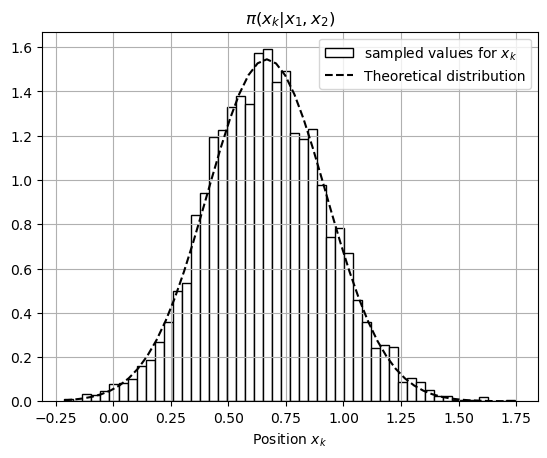

In [6]:
# Set up parametes
n_steps = 10_000
x = 0.0
x2 = 0.0
x1 = 1.0
dtau2 = 0.2
dtau1 = 0.1

# Sample points
x_values = naive_path_slice(x, 
                            x1, x2,
                            dtau1, dtau2,
                            n_steps=n_steps)

# Compute distrivution parameters
mean = (x1 * dtau2 + x2 * dtau1) / (dtau1 + dtau2)
std = np.sqrt(1 / ((1 / dtau1) + (1 / dtau2)))
xspan = np.linspace(min(x_values), max(x_values))
pi_theo = gaussian.pdf(xspan, loc=mean, scale=std)

# Print estimated values
print('+----------------------------------------------+')
print(f"| Estimated mean = {np.mean(x_values):.4f} | True mean = {mean:.4f} |")
print(f"| Estimated  std = {np.std(x_values):.4f} | True std  = {std:.4f} |")
print('+----------------------------------------------+')

plt.hist(x_values, bins=50, density=True,
         color='white', edgecolor='black',
         label=r'sampled values for $x_k$')
plt.plot(xspan, pi_theo, '--', color='black',
         label='Theoretical distribution')
plt.grid()
plt.xlabel(r'Position $x_k$')
plt.legend()
plt.title(r'$\pi(x_k | x_1, x_2)$')
plt.show()

# Free Lévy path sampling

The probability $$\pi(x_k|x_1,x_2) \propto \exp\Big\{-\frac{(x_k - \langle x_k \rangle)^2}{2\sigma^2}\Big\}$$
gives the **statistical weight** for all paths that
1. Begin from $x_1$
2. Pass through $x_k$
3. End at $x_2$

Given endpoints  $x_0$ and $x_N$ we can sequentially sample a path by first drawing $x_1 \sim\pi(x_1|x_0, x_N)$, then drawing $x_2 \sim \pi(x_2|x_1,x_N)$ and so on until we have sampled the full path $x_0,x_1,x_2,\dots,x_N$. This give the following procedure:

In [18]:
def levy_free_path(start: float, end: float,
                   N: int, beta: float,
                   n_paths: int = 1_000) -> list[NDArray]:
    """
    Generate sample paths of a free Lévy trajectory 
    connecting two fixed endpoints using sequential conditional sampling.

    Parameters
    ----------
    start : float
        Initial position x_0 of the path.
    end : float
        Final position x_N of the path.
    N : int
        Number of time steps (the path has N+1 points including endpoints).
    beta : float
        Total imaginary time (inverse temperature). The time step is
        dtau = beta / N.
    n_paths : int, optional
        Number of independent paths to generate (default is 1000).

    Returns
    -------
    paths : list of numpy.ndarray
        A list containing `n_paths` arrays of shape (N+1,), where each
        array represents a sampled path starting at `start` and ending
        at `end`.
    """
    dtau = beta / N
    paths = []
    for step in range(n_paths):
        path = np.empty(N + 1)
        for k in range(1, N):
            dtau_prime = (N - k) * dtau
            mean = (dtau_prime * path[k - 1] + dtau * end) / (dtau + dtau_prime)
            std = np.sqrt(1.0 / (1.0 / dtau + 1.0 / dtau_prime))
            path[k] = np.random.normal(loc=mean, scale=std)
        # Add endpoints
        path[0], path[N] = start, end
        paths.append(path)
    return paths

Let's plot some Lévy paths!

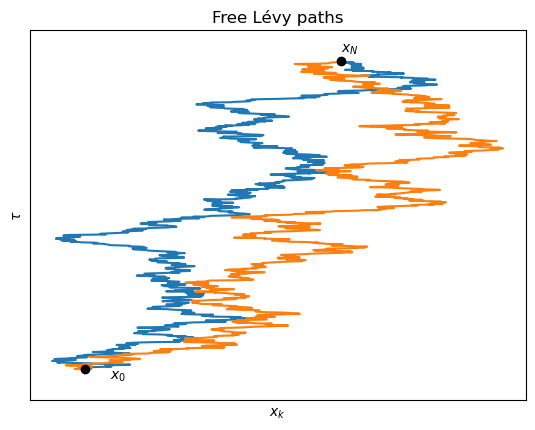

In [20]:
# Define values
n_paths = 2
N = 1_000
beta = 1.0
start, end = 0.0, 1.0

# Sample paths
paths = levy_free_path(start, end, N, beta, n_paths=n_paths)

# Plot parameters
tauspan = np.linspace(0, beta, N + 1)

# Plot all paths
for path in paths:
    plt.plot(path, tauspan,)
plt.grid()
plt.xlabel(r'$x_k$'); plt.ylabel(r"$\tau$")
plt.plot(start, 0, 'o', color='black'); plt.plot(end, beta, 'o', color='black');
plt.text(start + 0.1, -0.03, r"$x_0$"); plt.text(end, beta +0.03, r"$x_N$")
plt.title("Free Lévy paths")
plt.ylim(-0.1, 1.1)
plt.xticks([]); plt.yticks([]);
plt.show()

Without the condition that the path must end at $x_N$ it simply becomes a **random walk**.

In [23]:
def continuous_random_walk(N: int,
                          beta: float,
                          start: float = 0.0) -> NDArray:
    """
    Generate a one-dimensional continuous random walk.

    Parameters
    ----------
    N : int
        Number of points in the walk.
    beta : float
        Total time (or variance scale) of the process. The variance of each
        increment is `beta / N`.
    start : float, optional
        Initial value x_0 of the walk (default is 0.0).

    Returns
    -------
    numpy.ndarray
        Array of shape (N,) representing the sampled random walk.
    """
    std = np.sqrt(beta / N)
    walk = np.empty(N)
    walk[0] = start
    for k in range(1, N):
        walk[k] = np.random.normal(loc=walk[k-1], scale=std)
    return walk

There is also a *mysterious algorithm* `trivial_free_path`:

In [10]:
def trivial_free_path(start: float, end: float,
                      N: int, beta: float,
                      n_paths: int = 10
                     ) -> list[NDArray]:
    """
    Samples a free Lévy path.
    
    Parameters
    ----------
    start : float
        Initial point of the walk.
    end : float
        final point of the walk.
    N : int
        Number of points in the walk.
    beta : float
        Total variance (or time horizon) of the path.
    n_paths : int
        Number of paths to generate

    Returns
    -------
    list[numpy.ndarray]
        List of arrays of shape (N + 1,) containing the sampled trajectories.
    """
    k = np.arange(0, N + 1)
    paths = []
    for _ in range(n_paths):
        rw = continuous_random_walk(N + 1, beta, start=start)
        path = rw + (end - rw[-1]) * k / np.float64(N) # Isn't correct for k=0
        paths.append(
            np.where(k != 0, path, rw)
        )
    return paths

#### Exersise
Prove that `trivial_free_path` produces the same ouput as `levy_free_path`.

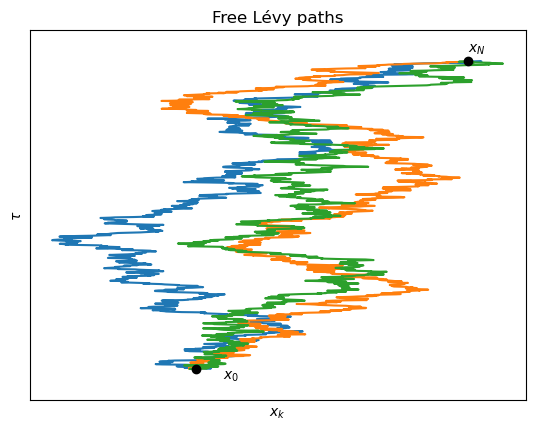

In [13]:
# Define values
n_paths = 3
N = 1024
beta = 1.0
start, end = 0.0, 1.0

# Sample paths
paths = trivial_free_path(start, end, N, beta, n_paths=n_paths)

# Plot parameters
tauspan = np.linspace(0, beta, N + 1)

# Plot all paths
for path in paths:
    plt.plot(path, tauspan,)
plt.grid()
plt.xlabel(r'$x_k$'); plt.ylabel(r"$\tau$")
plt.plot(start, 0, 'o', color='black'); plt.plot(end, beta, 'o', color='black');
plt.text(start + 0.1, -0.03, r"$x_0$"); plt.text(end, beta +0.03, r"$x_N$")
plt.title("Free Lévy paths")
plt.ylim(-0.1, 1.1)
plt.xticks([]); plt.yticks([]);
plt.show()

# Harmonic Lévy path sampling

We can prove that for the harmonic potential, the density matrix is given by

$$\rho^\text{harm}(x, x^\prime;\,\beta) = c(\beta) \exp\Big\{-g(\beta)\frac{(x - x^\prime)^2}{2}\Big\}\; \exp\Big\{ -f(\beta)\frac{(x + x^\prime)^2}{2}\Big\}$$

**for all temperatures** $\beta$, where the functions $c,g,f$ are as follows
$$\begin{aligned}
g(\beta) &= \frac{1}{2} \coth\frac{\beta}{2}\\
f(\beta) &= \frac{1}{2} \tanh\frac{\beta}{2}\\
c(\beta) &= \sqrt{\frac{1}{2\pi\sinh\beta}}
\end{aligned}$$

(For the derivation see the *factsheet*.)

Because the density matrix is a gaussian (product of gaussians) we can write a direct sampling algorithm

In [16]:
def levy_harmonic_path(start: float, end: float,
                       N: int, beta: float,
                       n_paths: int = 1_000) -> list[NDArray]:
    """
    Lévy sampling of a path in imaginary time for a particle in a harmonic trap.

    Parameters
    ----------
    start : float
        Initial position x_0 of the path.
    end : float
        Final position x_N of the path.
    N : int
        Number of time steps (the path has N+1 points including endpoints).
    beta : float
        Total imaginary time (inverse temperature). The time step is
        dtau = beta / N.
    n_paths : int, optional
        Number of independent paths to generate (default is 1000).

    Returns
    -------
    paths : list of numpy.ndarray
        A list containing `n_paths` arrays of shape (N+1,), where each
        array represents a sampled path starting at `start` and ending
        at `end`.
    """
    dtau = beta / N
    paths = []
    for step in range(n_paths):
        path = np.empty(N + 1)
        for k in range(1, N):
            dtau_prime = (N - k) * dtau
            Ups1 = 1.0 / np.tanh(dtau) + 1.0 / np.tanh(dtau_prime)
            Ups2 = path[k - 1] / np.sinh(dtau) + end / np.sinh(dtau_prime) 
            path[k] = np.random.normal(
                loc   = Ups2 / Ups1,
                scale = 1.0 / np.sqrt(Ups1))
        # Add endpoints
        path[0], path[N] = start, end
        paths.append(path)
    return paths

The algorithm works by using the fact that the if a random variable $Z$ is the product two random variables $X \sim \mathcal{N}(\mu_x, \sigma_x)$ and $Y \sim \mathcal{N}(\mu_y, \sigma_y)$ then 

$$Z\sim \mathcal{N}(\mu, \sigma)$$

where

$$\begin{aligned}
\sigma^2 &= \Big(\frac{1}{\sigma^2_x} + \frac{1}{\sigma^2_y} \Big)^{-1}\\
\mu &= \sigma^2 \Big( \frac{\mu_x}{\sigma^2_x} + \frac{\mu_y}{\sigma^2_y}\Big)
\end{aligned}$$

---

Let's plot some Lévy paths!ot some paths

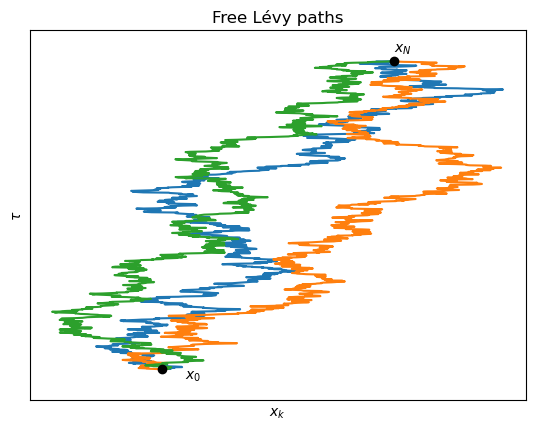

In [17]:
# Define values
n_paths = 3
N = 1024
beta = 1.0
start, end = 0.0, 1.0

# Sample paths
paths = levy_harmonic_path(start, end, N, beta, n_paths=n_paths)

# Plot parameters
tauspan = np.linspace(0, beta, N + 1)

# Plot all paths
for path in paths:
    plt.plot(path, tauspan,)
plt.grid()
plt.xlabel(r'$x_k$'); plt.ylabel(r"$\tau$")
plt.plot(start, 0, 'o', color='black'); plt.plot(end, beta, 'o', color='black');
plt.text(start + 0.1, -0.03, r"$x_0$"); plt.text(end, beta +0.03, r"$x_N$")
plt.title("Free Lévy paths")
plt.ylim(-0.1, 1.1)
plt.xticks([]); plt.yticks([]);
plt.show()